In [2]:
import xarray as xr
import numpy as np
import rioxarray
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pymannkendall as mk
from dask.diagnostics import ProgressBar

In [3]:
#load data
MASK_PATH = "/mnt/data7/nfs4/avh_lst/sdupuis/auxiliary/watermask50.tif"
clim = xr.open_dataset('../outputs/combined_monthly_NIGHT_2008_2020_coarse.nc')

In [5]:
print("Loading water mask...")
clouds = xr.open_dataset('../data/ice_flc_percent_2008_2020_2deg.nc')
example = clouds['ice_flc_percent'].isel(year=1, month=1)

water_mask = rioxarray.open_rasterio(MASK_PATH).squeeze()

water_mask = water_mask.rename({'y':'lat', 'x':'lon'})
water_mask = water_mask.isel(lat=slice(None, None, -1))
water_interp = water_mask.interp(lat=clim.coords['lat'], lon=clim.coords['lon'], method='nearest')

water_mask_true = clim['LST'].isel(time=0).copy(data=np.array(np.squeeze(water_interp)))
ls_mask = water_mask_true.where(water_mask_true>0, np.nan)


Loading water mask...


In [7]:
# compute trends
winter = clim['LST'].sel(time=clim.time.dt.month.isin([1,2, 12]))
winter['time']= winter['time'] + np.timedelta64(10000000000000000, 'ns')
winter_data = winter.groupby('time.year').mean()
winter_masked = winter_data * ls_mask
winter_masked = winter_masked.chunk({'year':-1, 'lon':1000, 'lat':100})

In [8]:
def mk_test_p(y):
    if np.count_nonzero(np.isnan(y)) > 9:
        #print('catched_error')
        return np.nan
    #results = mk.original_test(y).slope
    p_vals = mk.original_test(y).p
    return p_vals

def mann_kendall_p(y, dim):
    return xr.apply_ufunc(
        mk_test_p,
        y,
        input_core_dims=[[dim]],
        dask ='parallelized',
        vectorize=True,
        output_dtypes=[float],)

In [9]:
with ProgressBar():
    p_val_winter = mann_kendall_p(winter_masked, dim="year").compute()
    # mask out oceans
p_val_winter_masked = p_val_winter*ls_mask
ds_p_val = p_val_winter_masked.to_dataset(name='p_val')
ds_p_val.to_netcdf('winter_p_val_NIGHT_02deg_coarse.nc', format='NETCDF4')

[########################################] | 100% Completed | 1.24 ss


In [10]:
def mk_test(y):
    if np.count_nonzero(np.isnan(y)) > 9:
        #print('catched_error')
        return np.nan
    results = mk.original_test(y).slope
    #p_vals = mk.original_test(y).p
    return results

In [11]:
def mann_kendall(y, dim):
    return xr.apply_ufunc(
        mk_test,
        y,
        input_core_dims=[[dim]],
        dask ='parallelized',
        vectorize=True,
        output_dtypes=[float],)

In [12]:
with ProgressBar():
    res = mann_kendall(winter_masked, dim="year").compute()

[########################################] | 100% Completed | 1.12 ss


In [13]:
# mask out oceans
res_masked = res*ls_mask

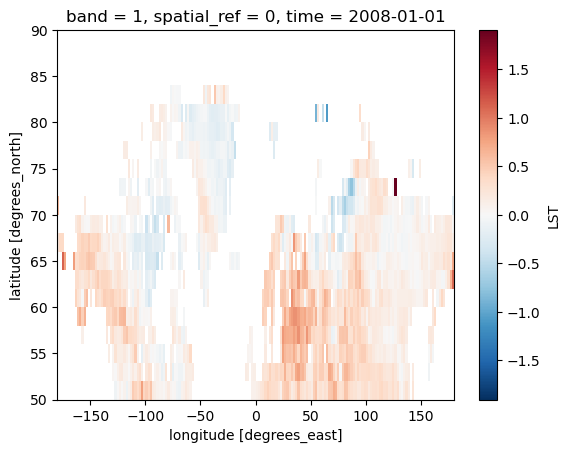

In [14]:
# apply mask and then save the data! 
res_masked.plot();

In [15]:
ds_trend = res_masked.to_dataset(name='trend')
ds_trend.to_netcdf('winter_trend_NIGHT_02deg_coarse.nc', format='NETCDF4')

In [16]:
# compute trends
spring = clim['LST'].sel(time=clim.time.dt.month.isin([3,4, 5]))
spring_data = spring.groupby('time.year').mean()
spring_data = spring_data.chunk({'year':-1, 'lon':1000, 'lat':100})

In [17]:
with ProgressBar():
    res_spring = mann_kendall(spring_data, dim="year").compute()

[########################################] | 100% Completed | 2.83 ss


In [18]:
spring_masked = res_spring*ls_mask
spring_trend = spring_masked.to_dataset(name='trend')
spring_trend.to_netcdf('spring_trend_NIGHT_02deg_coarse.nc', format='NETCDF4')

In [19]:
with ProgressBar():
    p_val_spring = mann_kendall_p(spring_data, dim="year").compute()
    # mask out oceans
p_val_spring_masked = p_val_spring*ls_mask
ds_p_val_spring = p_val_spring_masked.to_dataset(name='p_val')
ds_p_val_spring.to_netcdf('spring_p_val_NIGHT_02deg_coarse.nc', format='NETCDF4')

[########################################] | 100% Completed | 2.69 ss


In [20]:
# compute trends
summer = clim['LST'].sel(time=clim.time.dt.month.isin([6,7, 8]))
summer_data = summer.groupby('time.year').mean()
summer_data = summer_data.chunk({'year':-1, 'lon':1000, 'lat':100})
with ProgressBar():
    res_summer = mann_kendall(summer_data, dim="year").compute()

[########################################] | 100% Completed | 2.71 ss


In [21]:
summer_masked = res_summer*ls_mask
summer_trend = summer_masked.to_dataset(name='trend')
summer_trend.to_netcdf('summer_trend_NIGHT_02deg_coarse.nc', format='NETCDF4')

In [22]:
with ProgressBar():
    p_val_summer = mann_kendall_p(summer_data, dim="year").compute()
    # mask out oceans
p_val_summer_masked = p_val_summer*ls_mask
ds_p_val_summer = p_val_summer_masked.to_dataset(name='p_val')
ds_p_val_summer.to_netcdf('summer_p_val_NIGHT_02deg_coarse.nc', format='NETCDF4')

[########################################] | 100% Completed | 2.70 ss


In [23]:
# compute trends
fall = clim['LST'].sel(time=clim.time.dt.month.isin([9,10, 11]))
fall_data = fall.groupby('time.year').mean()
fall_data = fall_data.chunk({'year':-1, 'lon':1000, 'lat':100})
with ProgressBar():
    res_fall = mann_kendall(fall_data, dim="year").compute()

[########################################] | 100% Completed | 2.68 ss


In [ ]:
fall_masked = res_fall*ls_mask
fall_trend = fall_masked.to_dataset(name='trend')
fall_trend.to_netcdf('fall_trend_NIGHT_02deg_coarse.nc', format='NETCDF4')

In [24]:
with ProgressBar():
    p_val_fall = mann_kendall_p(fall_data, dim="year").compute()
    # mask out oceans
p_val_fall_masked = p_val_fall*ls_mask
ds_p_val_fall = p_val_fall_masked.to_dataset(name='p_val')
ds_p_val_fall.to_netcdf('fall_p_val_NIGHT_02deg_coarse.nc', format='NETCDF4')

[########################################] | 100% Completed | 2.67 ss


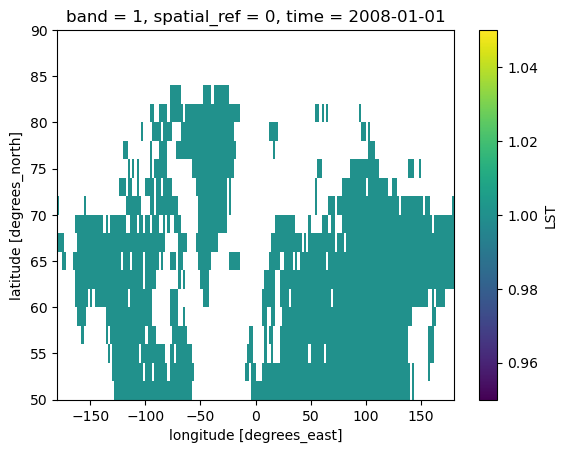

In [25]:
ls_mask.plot()